In [ ]:
import pandas as pd # Descargamos todos los paquetes y librerías que vamos a utilizar
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

In [ ]:
from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()

Saving natalidad.csv to natalidad.csv


In [ ]:
import io
tabla = pd.read_csv(io.BytesIO(uploaded['natalidad.csv']), sep = ";", index_col=0, encoding='latin-1')
tabla.head(4)

/tmp/ipykernel_16877/522668122.py:2: DtypeWarning: Columns (4,14,22,28) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv(io.BytesIO(uploaded['natalidad.csv']), sep = ";", index_col=0, encoding='latin-1')


,areanac,cod_insp,sit_parto,otro_sit,nom_inst,cod_inst,sexo,peso_nac,talla_nac,fecha_nac,...,n_emb,seg_social,idclasadmi,nomclasad,codclasad,edad_padre,niv_edup,ultcurpad,barrio_res,comuna_res
id,,,,,,,,,,,,,,,,,,,,,
1,1,NaN,1,NaN,PROMOTORA MEDICA LAS AMERICAS S.A,5.001021e+10,2,1070,38,23/04/2012,...,4,1,1.0,COOMEVA E.P.S. S.A.,EPS016,42,4,11,El RincÃ³n,16 Belen
2,1,NaN,1,NaN,CLINICA DEL PRADO S.A.,5.001046e+10,2,2900,47,30/05/2012,...,1,1,1.0,SALUD TOTAL S.A. ENTIDAD PROMOTORA DE SALUD,EPS002,25,99,9,Versalles N.2,03 Manrique
3,1,NaN,1,NaN,CLINICA UNIVERSITARIA BOLIVARIANA,5.001034e+10,2,2510,48,04/06/2012,...,2,5,NaN,NaN,NaN,34,8,3,Santa MÃ³nica,12 La America
4,1,NaN,1,NaN,UNIDAD HOSPITALARIA DE MANRRIQUE HERMENEGILDO ...,5.001022e+10,1,3400,50,25/09/2012,...,1,5,NaN,NaN,NaN,24,99,9,Enciso,08 Villa Hermosa


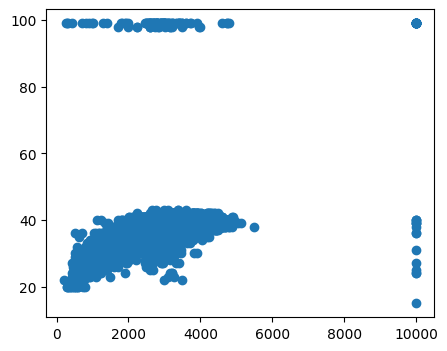

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.scatter(tabla["peso_nac"], tabla["t_ges"])
plt.show()

In [ ]:
sin_atipicos = tabla[(tabla["peso_nac"] < 6000) & (tabla["t_ges"] < 50) & (tabla["edad_madre"] < 99) & (tabla["edad_padre"] < 99)]
print(sin_atipicos.head())

    areanac  cod_insp  sit_parto otro_sit  \
id                                          
1         1       NaN          1      NaN   
2         1       NaN          1      NaN   
3         1       NaN          1      NaN   
4         1       NaN          1      NaN   
5         1       NaN          1      NaN   

                                             nom_inst      cod_inst  sexo  \
id                                                                          
1                   PROMOTORA MEDICA LAS AMERICAS S.A  5.001021e+10     2   
2                              CLINICA DEL PRADO S.A.  5.001046e+10     2   
3                   CLINICA UNIVERSITARIA BOLIVARIANA  5.001034e+10     2   
4   UNIDAD HOSPITALARIA DE MANRRIQUE HERMENEGILDO ...  5.001022e+10     1   
5   UNIDAD HOSPITALARIA DE MANRRIQUE HERMENEGILDO ...  5.001022e+10     1   

    peso_nac  talla_nac   fecha_nac  ...  n_emb  seg_social  idclasadmi  \
id                                   ...                             

In [ ]:
df = sin_atipicos[["peso_nac", "t_ges", "edad_madre", "edad_padre"]]
df

,peso_nac,t_ges,edad_madre,edad_padre
id,,,,
1,1070,30,39,42
2,2900,40,21,25
3,2510,36,37,34
4,3400,41,22,24
5,3760,39,40,41
...,...,...,...,...
196725,3150,40,33,36
196726,2310,36,31,42
196727,2600,36,29,33


In [ ]:
x = df[["t_ges", "edad_madre", "edad_padre"]]
y = df["peso_nac"]
print(x.head(2))

    t_ges  edad_madre  edad_padre
id                               
1      30          39          42
2      40          21          25


In [ ]:
trainX, testX, trainY, testY = train_test_split(x, y, test_size = 0.3, random_state=0)
sc=StandardScaler()
scaler = sc.fit(trainX)
trainX_scaled = scaler.transform(trainX)
testX_scaled = scaler.transform(testX)
testX = testX.to_numpy()

In [ ]:
mlp_reg = MLPRegressor(hidden_layer_sizes=(15,10,20),
                       max_iter = 100, activation = 'relu',
                       solver = 'adam', learning_rate = 'invscaling')
mlp_reg.fit(trainX_scaled, trainY) # Se estiman los parámetros de la red con los datos de entrenamiento

MLPRegressor(hidden_layer_sizes=(15, 10, 20), learning_rate='invscaling',
             max_iter=100)

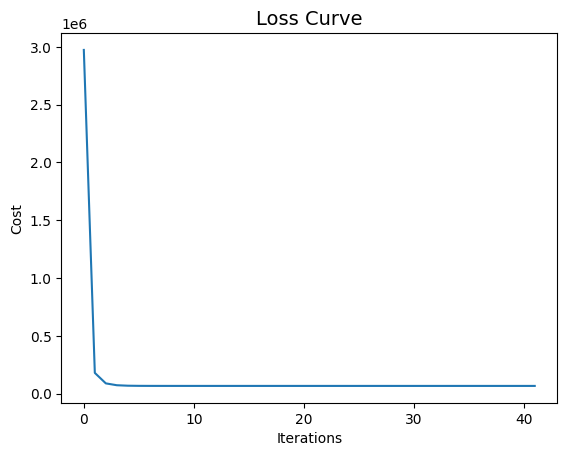

In [ ]:
plt.plot(mlp_reg.loss_curve_)
plt.title("Loss Curve", fontsize=14)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

In [ ]:
y_pred = mlp_reg.predict(testX_scaled)
y_pred

array([3016.94504476, 3181.7016086 , 2134.81109754, ..., 2996.80598017,
       3436.54985158, 3217.06090443])

In [ ]:
metrics.r2_score(testY, y_pred)

0.45970462762147424

In [ ]:
from sklearn.linear_model import LinearRegression ## Modelo de regresión lineal múltiple
modelo1 = LinearRegression()
modelo1.fit(trainX_scaled, trainY) # Estimación de parámetros sobre los datos de entrenamiento

LinearRegression()

In [ ]:
y_predlineal = modelo1.predict(testX_scaled)
print('Error medio absoluto red:', metrics.mean_absolute_error(testY, y_pred),
      'Error medio absoluto lineal:', metrics.mean_absolute_error(testY, y_predlineal))
print('Error cuadrático medio red:', metrics.mean_squared_error(testY, y_pred),
      'Error cuadrático medio lineal:', metrics.mean_squared_error(testY, y_predlineal))
print('Coeficiente de determinación red:', metrics.r2_score(testY, y_pred),
      'Coeficiente de determinación lineal:', metrics.r2_score(testY, y_predlineal))

Error medio absoluto red: 286.3468006836706 Error medio absoluto lineal: 286.6163394385114
Error cuadrático medio red: 132455.620283455 Error cuadrático medio lineal: 132591.72404685288
Coeficiente de determinación red: 0.45970462762147424 Coeficiente de determinación lineal: 0.45914945122828077


In [ ]:
from sklearn.ensemble import RandomForestRegressor
modelo_rf = RandomForestRegressor(
    n_estimators=300,      # número de árboles
    max_depth=None,        # profundidad libre
    random_state=42,
    n_jobs=-1              # uso de todos los núcleos del CPU
)

In [ ]:
modelo_rf.fit(trainX_scaled, trainY) # Entrenamiento
y_predrf = modelo_rf.predict(testX_scaled) # Para la validación
r2rf = metrics.r2_score(testY, y_predrf)
r2rf

0.4442223208246767

In [ ]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

feature_map_nystroem = Nystroem(gamma=0.2, n_components=400)
approx_rbf = make_pipeline(feature_map_nystroem, Ridge(alpha=2.0))

In [ ]:
approx_rbf.fit(trainX_scaled, trainY) # Entrenamiento
y_predrbf = approx_rbf.predict(testX_scaled) # Para la validación
r2rbf = metrics.r2_score(testY, y_predrbf )
r2rbf

0.4721217198227692

In [ ]:
datos_faltantes = tabla[(tabla["peso_nac"] > 6000) & (tabla["t_ges"] < 50) & (tabla["edad_madre"] < 99) & (tabla["edad_padre"] < 99)]
df1 = datos_faltantes[["peso_nac", "t_ges", "edad_madre", "edad_padre"]]
df1.head(4)

,peso_nac,t_ges,edad_madre,edad_padre
id,,,,
10624,9999,40,34,44
11412,9999,36,16,42
19848,9999,40,23,18
26901,9999,36,29,30


In [ ]:
X_df1 = df1[["t_ges", "edad_madre", "edad_padre"]].to_numpy()
X_df1_scaled = scaler.transform(X_df1)
df1["peso_nac"] = approx_rbf.predict(X_df1_scaled)
df1.head(4)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_16877/2853103613.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["peso_nac"] = approx_rbf.predict(X_df1_scaled)


,peso_nac,t_ges,edad_madre,edad_padre
id,,,,
10624,3380.703150,40,34,44
11412,2610.123876,36,16,42
19848,3280.782387,40,23,18
26901,2644.470978,36,29,30


Note que para la imputación de valores faltantes se ha utilizado un modelo bajo el cual se tiene mejor ajuste. En este caso puntual, se quiere determinar si el tiempo de gestación, la edad de la madre y la edad del padre **tienen efecto** en el peso de un recién nacido.

Ello implica realizar primero un análisis descriptivo, mediante los diagramas de dispersión.

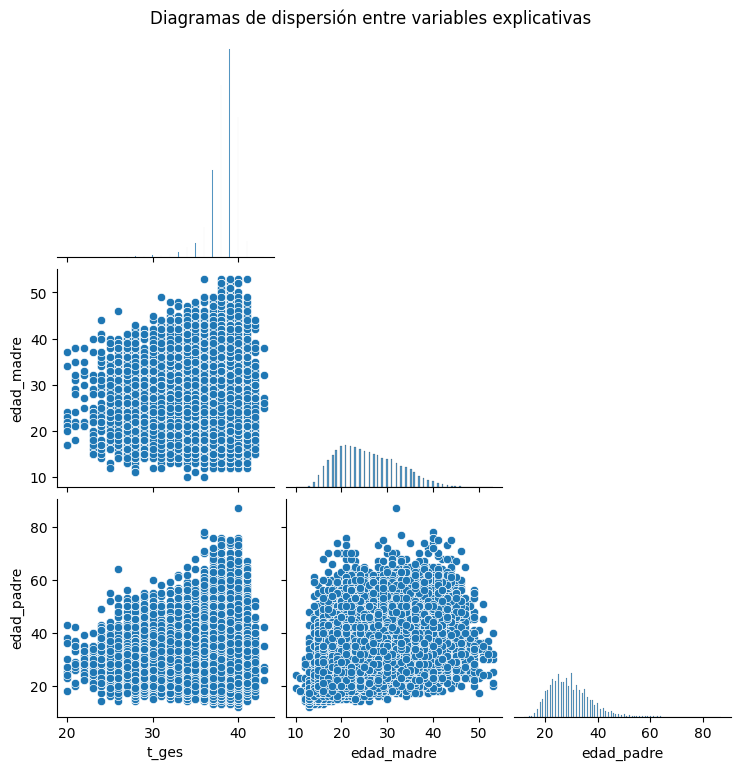

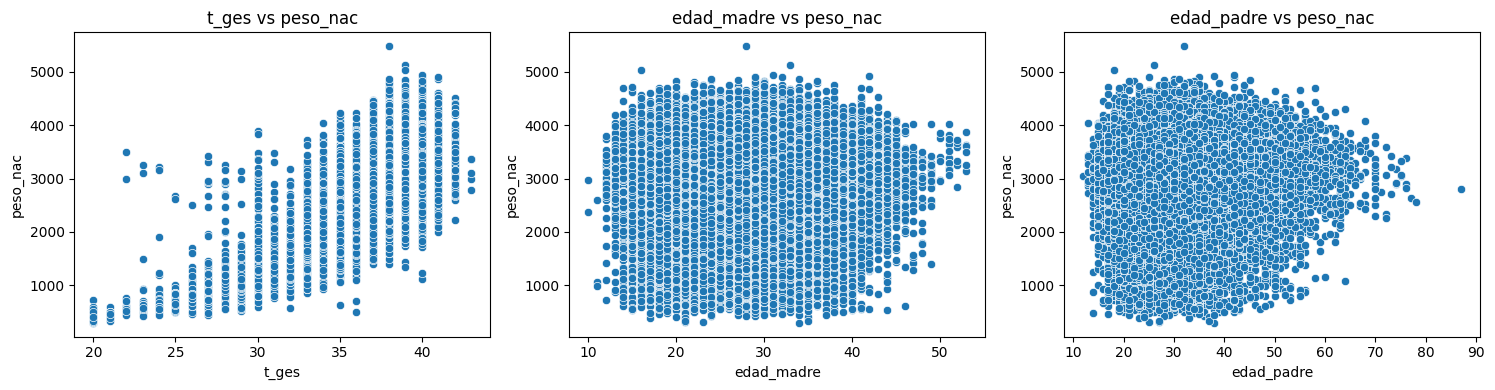

In [ ]:
import seaborn as sns

# Variables numéricas (excepto peso)
vars_exp = ["t_ges", "edad_madre", "edad_padre"]

# --- 1. Diagramas de dispersión entre variables explicativas ---
sns.pairplot(df, vars=vars_exp, corner=True)
plt.suptitle("Diagramas de dispersión entre variables explicativas", y=1.02)
plt.show()

# --- 2. Diagramas de dispersión de cada variable contra el peso ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, var in enumerate(vars_exp):
    sns.scatterplot(data=df, x=var, y="peso_nac", ax=axes[i])
    axes[i].set_title(f"{var} vs peso_nac")

plt.tight_layout()
plt.show()

Se acompaña ahora con un análisis inferencial, determinando los valores p bajo la hipótesis nula de que cada uno de los parámetros sean iguales a cero.

In [ ]:
import statsmodels.api as sm

X_scaled = scaler.transform(x)
X_const = sm.add_constant(X_scaled)  # Agregar intercepto

modelo1 = sm.OLS(y, X_const).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:               peso_nac   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                 5.397e+04
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        23:04:30   Log-Likelihood:            -1.3937e+06
No. Observations:              190502   AIC:                         2.787e+06
Df Residuals:                  190498   BIC:                         2.787e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3058.3253      0.834   3668.239      0.0

Se hace un muestreo aleatorio simple con reemplazo. Esto porque cuando $n \to \infty$ siempre se rechaza la hipótesis nula.

In [ ]:
idx = np.random.choice(len(y), size=100, replace=True)
X_muestra = X_const[idx]
y_muestra = y.to_numpy()[idx]  # si y es serie pandas
modelo2 = sm.OLS(y_muestra, X_muestra).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     38.12
Date:                Sun, 03 May 2026   Prob (F-statistic):           2.60e-16
Time:                        23:04:35   Log-Likelihood:                -714.61
No. Observations:                 100   AIC:                             1437.
Df Residuals:                      96   BIC:                             1448.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3098.3191     31.529     98.270      0.0

In [ ]:
n_iter = 1000  # Número de réplicas bootstrap
pvalues_x1 = []  # Guardar valores p del parámetro x1

for i in range(n_iter):
    idx = np.random.choice(len(y), size= 100, replace=True)

    X_boot = X_const[idx]
    y_boot = y.to_numpy()[idx]

    modelo_boot = sm.OLS(y_boot, X_boot).fit()

    # p-value del coeficiente de x1 -> posición 1 (0 = intercepto)
    pvalues_x1.append(modelo_boot.pvalues[1])

pvalues_x1 = np.array(pvalues_x1)

print("Media de p-values:", np.mean(pvalues_x1))
print("Proporción de p-values < 0.05:",
      np.mean(pvalues_x1 < 0.05))

Media de p-values: 1.898394260980321e-06
Proporción de p-values < 0.05: 1.0


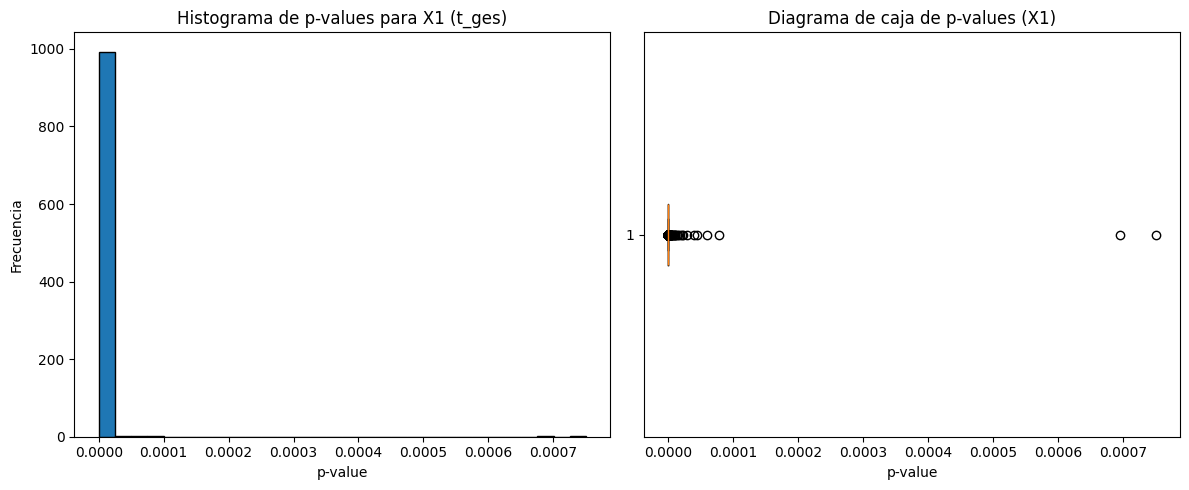

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(pvalues_x1, bins=30, edgecolor='black')
plt.title("Histograma de p-values para X1 (t_ges)")
plt.xlabel("p-value")
plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
plt.boxplot(pvalues_x1, vert=False)
plt.title("Diagrama de caja de p-values (X1)")
plt.xlabel("p-value")

plt.tight_layout()
plt.show()

In [ ]:
n_iter = 1000  # Número de réplicas bootstrap
pvalues_x2 = []  # Guardar valores p del parámetro x1

for i in range(n_iter):
    idx = np.random.choice(len(y), size= 100, replace=True)

    X_boot = X_const[idx]
    y_boot = y.to_numpy()[idx]

    modelo_boot = sm.OLS(y_boot, X_boot).fit()

    # p-value del coeficiente de x1 -> posición 1 (0 = intercepto)
    pvalues_x2.append(modelo_boot.pvalues[2])

pvalues_x2 = np.array(pvalues_x2)

print("Media de p-values:", np.mean(pvalues_x2))
print("Proporción de p-values < 0.05:",
      np.mean(pvalues_x2 < 0.05))

Media de p-values: 0.4585579908500363
Proporción de p-values < 0.05: 0.085


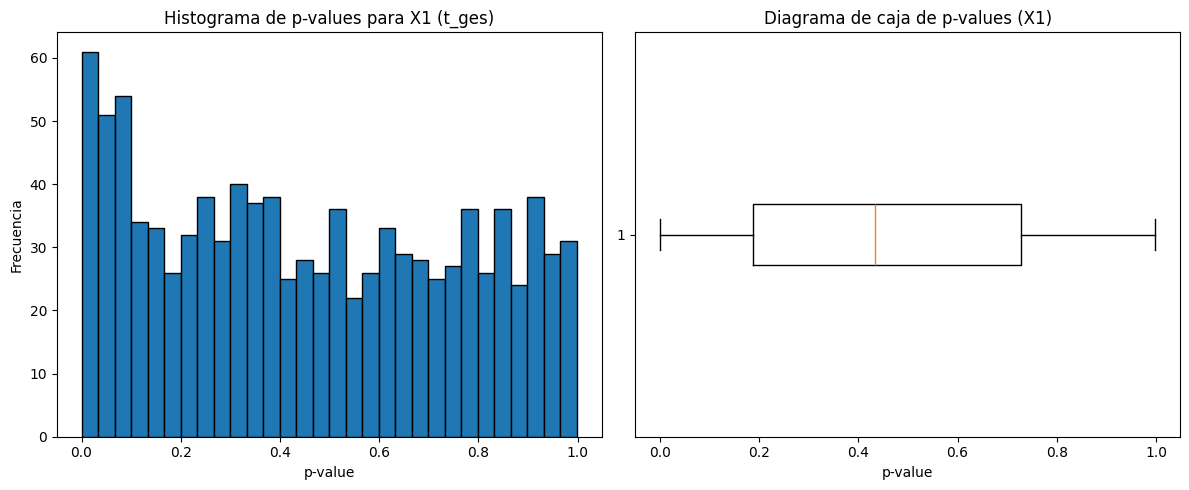

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(pvalues_x2, bins=30, edgecolor='black')
plt.title("Histograma de p-values para X1 (t_ges)")
plt.xlabel("p-value")
plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
plt.boxplot(pvalues_x2, vert=False)
plt.title("Diagrama de caja de p-values (X1)")
plt.xlabel("p-value")

plt.tight_layout()
plt.show()

In [ ]:
n_iter = 1000  # Número de réplicas bootstrap
pvalues_x3 = []  # Guardar valores p del parámetro x1

for i in range(n_iter):
    idx = np.random.choice(len(y), size= 100, replace=True)

    X_boot = X_const[idx]
    y_boot = y.to_numpy()[idx]

    modelo_boot = sm.OLS(y_boot, X_boot).fit()

    # p-value del coeficiente de x1 -> posición 1 (0 = intercepto)
    pvalues_x3.append(modelo_boot.pvalues[3])

pvalues_x3 = np.array(pvalues_x3)

print("Media de p-values:", np.mean(pvalues_x3))
print("Proporción de p-values < 0.05:",
      np.mean(pvalues_x3 < 0.05))

Media de p-values: 0.48830417936172343
Proporción de p-values < 0.05: 0.064


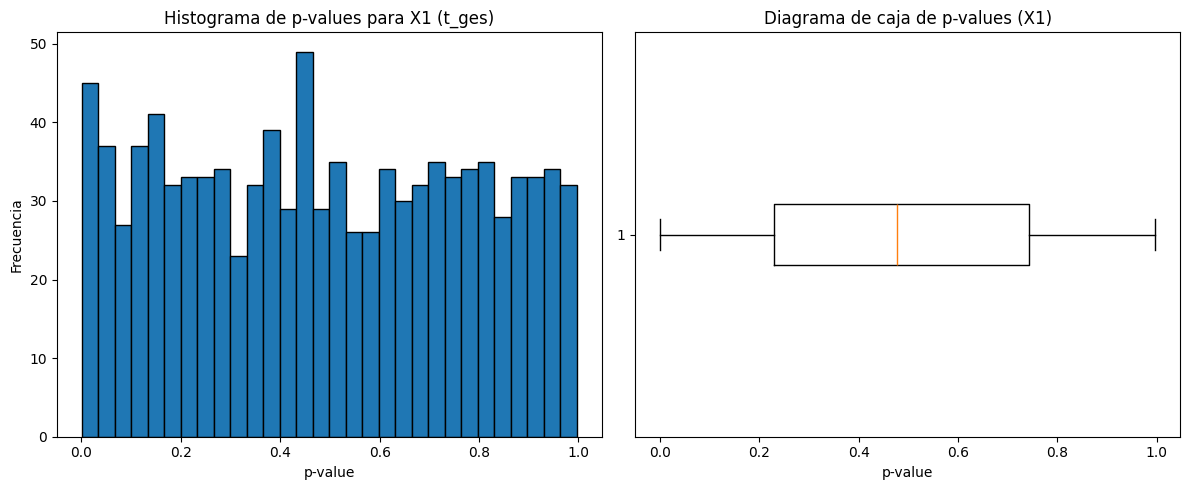

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(pvalues_x3, bins=30, edgecolor='black')
plt.title("Histograma de p-values para X1 (t_ges)")
plt.xlabel("p-value")
plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
plt.boxplot(pvalues_x3, vert=False)
plt.title("Diagrama de caja de p-values (X1)")
plt.xlabel("p-value")

plt.tight_layout()
plt.show()